# Predicting Depression Risk Among University Students
**Mission:** Improve mental health outcomes among university students by predicting
depression risk factors using machine learning. Early identification of at-risk
students enables timely intervention and support.

**Dataset:** Bangladeshi University Students Mental Health  
**Source:** https://www.kaggle.com/datasets/arfintanim/bangladeshi-uni-students-mental-health  
**Target Variable:** Depression level score

## 1. Load & Explore Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.edgecolor': '#cccccc',
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
})

In [2]:
df = pd.read_csv('Raw Data.csv')
df.shape

(1977, 39)

In [3]:
df = df.rename(columns={
    '1. Age': 'Age',
    '6. Current CGPA': 'CGPA',
    '1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ': 'Anxiety',
    '3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much? ': 'Sleep',
    'Depression Value': 'Depression'
})

In [4]:
df.head()

,Age,2. Gender,3. University,4. Department,5. Academic Year,CGPA,7. Did you receive a waiver or scholarship at your university?,Anxiety,"2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?",Sleep,"4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression,Depression Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.80 - 4.00,No,2,2,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,1,1,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,2,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [5]:
# confirm no null values
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.dtypes.value_counts()

,count
int64,29
object,10


##2. Visualizations

Exploring distributions and relationships between features and depression score.
These insights guide which columns carry predictive weight.

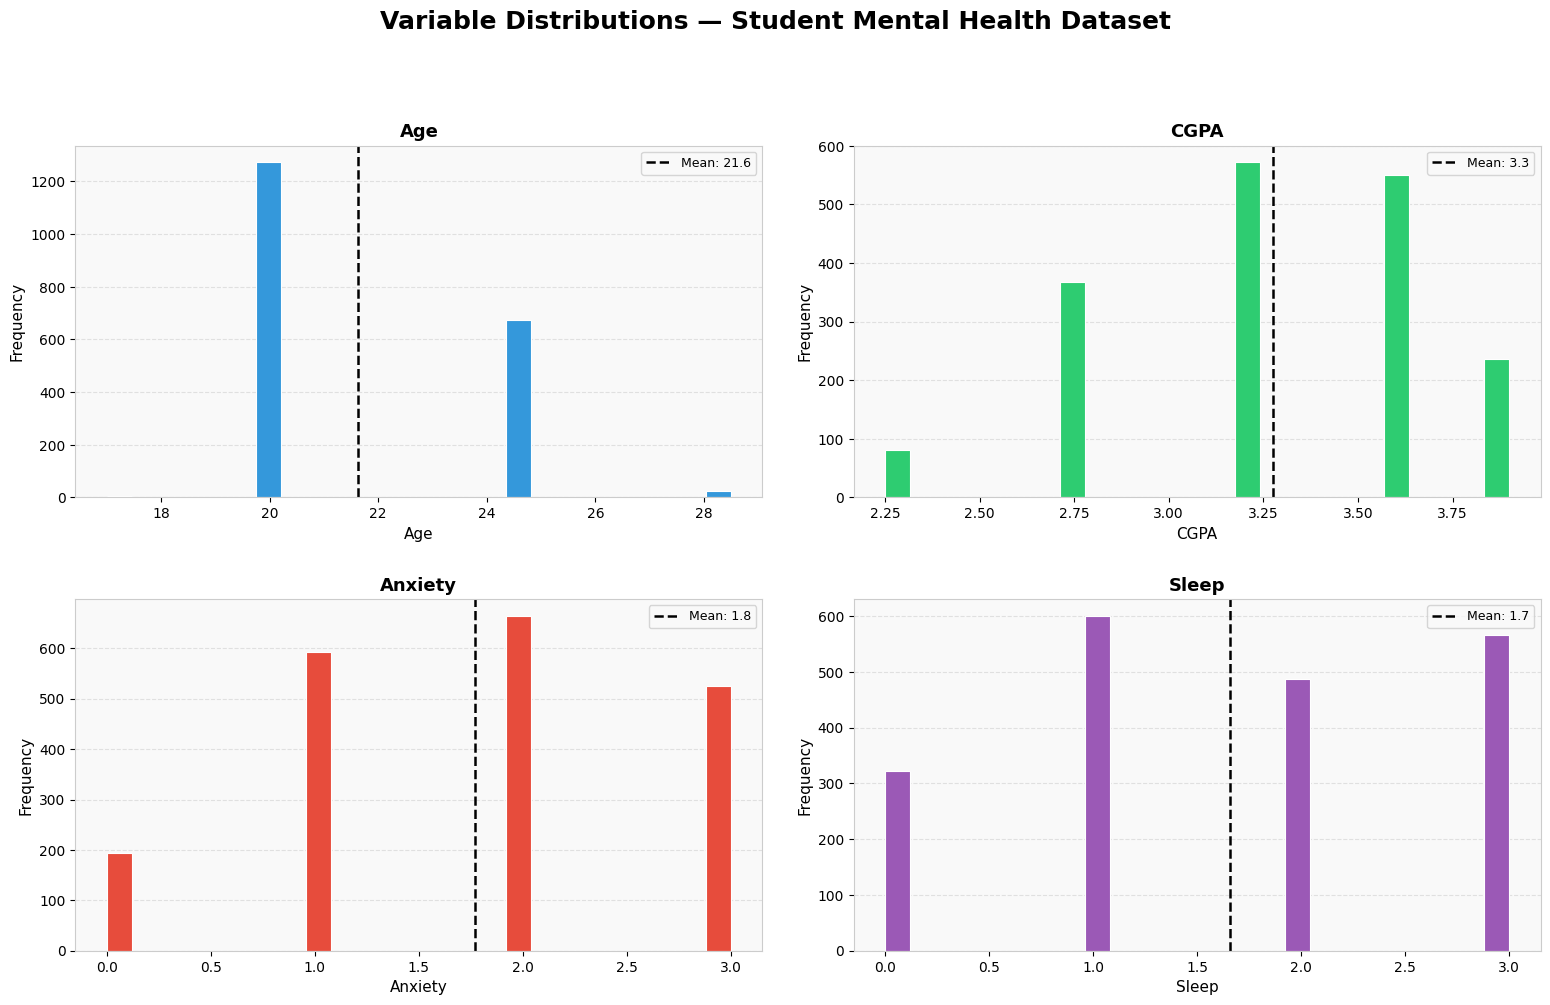

In [7]:
cols_to_plot = ['Age', 'CGPA', 'Anxiety', 'Sleep']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Variable Distributions — Student Mental Health Dataset',
             fontsize=18, fontweight='bold', y=1.02)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

for i, (col, ax) in enumerate(zip(cols_to_plot, axes.flatten())):
    plot_data = df[col].copy()

    if plot_data.dtype == 'object':
        if col == 'Age':
            age_mapping = {
                'Below 18': 17,
                '18-22': 20,
                '23-26': 24.5,
                '27-30': 28.5,
                'Above 35': 36
            }
            plot_data = plot_data.map(age_mapping).astype(float)
        elif col == 'CGPA':
            cgpa_mapping = {
                'Below 2.50': 2.25,
                '2.50 - 2.99': 2.745,
                '3.00 - 3.39': 3.195,
                '3.40 - 3.79': 3.595,
                '3.80 - 4.00': 3.90
            }
            plot_data = plot_data.map(cgpa_mapping).astype(float)

    ax.hist(plot_data, bins=25, color=colors[i], edgecolor='white', linewidth=0.8)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    if pd.api.types.is_numeric_dtype(plot_data):
        mean_val = plot_data.mean()
        ax.axvline(mean_val, color='black', linewidth=1.8,
                   linestyle='--', label=f'Mean: {mean_val:.1f}')
        ax.legend(fontsize=9)

plt.tight_layout(pad=2.5)
plt.show()

# each histogram shows how students are distributed across key variables
# the dashed mean line shows where the average student falls

## Visualization Insights

- **Age**: Most students fall in the 18-22 range, reflecting a typical university population.
  The distribution is right-skewed, meaning older students are underrepresented.

- **CGPA**: The majority of students have a CGPA between 3.00-3.79, suggesting
  most are average to above-average performers academically.

- **Anxiety**: Scores are spread across all levels with a mean around 1.8,
  indicating a significant portion of students experience moderate to high anxiety.

- **Sleep**: Similar to anxiety, sleep trouble is widely distributed,
  with many students reporting frequent sleep difficulties.

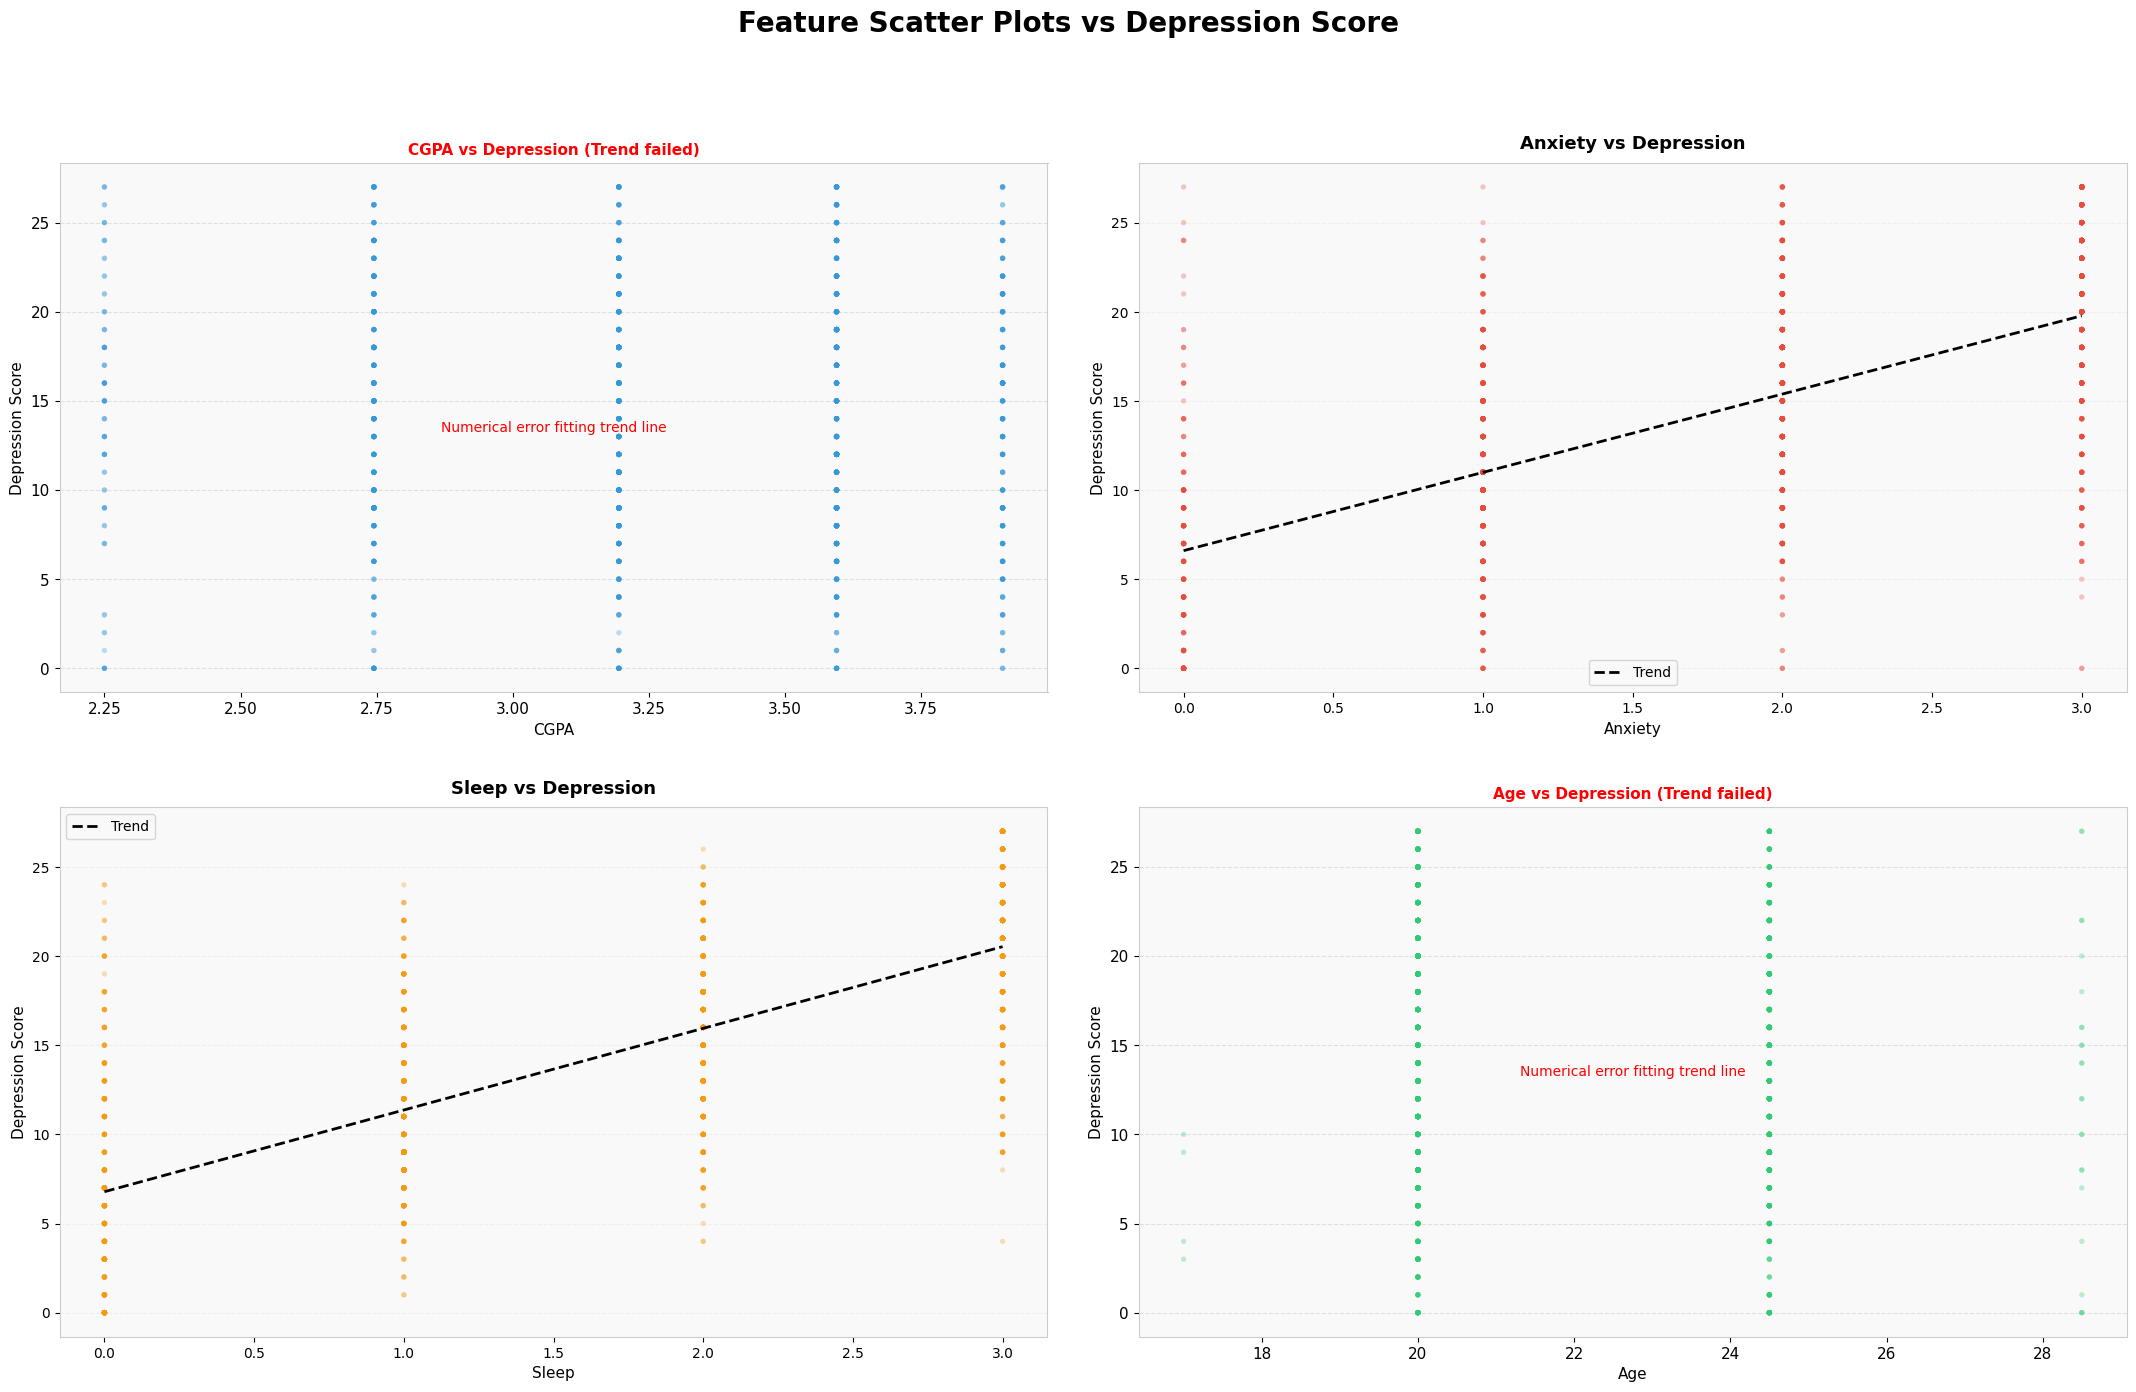

In [8]:
scatter_cols = ['CGPA', 'Anxiety', 'Sleep', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle('Feature Scatter Plots vs Depression Score',
             fontsize=20, fontweight='bold', y=1.01)

colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

age_mapping = {
    'Below 18': 17,
    '18-22': 20,
    '23-26': 24.5,
    '27-30': 28.5,
    'Above 35': 36
}
cgpa_mapping = {
    'Below 2.50': 2.25,
    '2.50 - 2.99': 2.745,
    '3.00 - 3.39': 3.195,
    '3.40 - 3.79': 3.595,
    '3.80 - 4.00': 3.90
}

for i, (col, ax) in enumerate(zip(scatter_cols, axes.flatten())):
    plot_x_data = df[col].copy()

    if col == 'Age' and plot_x_data.dtype == 'object':
        plot_x_data = plot_x_data.map(age_mapping).astype(float)
    elif col == 'CGPA' and plot_x_data.dtype == 'object':
        plot_x_data = plot_x_data.map(cgpa_mapping).astype(float)

    ax.scatter(plot_x_data, df['Depression'],
               alpha=0.3, color=colors[i], edgecolors='none', s=15)

    if pd.api.types.is_numeric_dtype(plot_x_data) and pd.api.types.is_numeric_dtype(df['Depression']):
        try:
            if plot_x_data.std() > 1e-9:
                z = np.polyfit(plot_x_data.astype(float), df['Depression'].astype(float), 1)
                p = np.poly1d(z)
                x_sorted = np.linspace(plot_x_data.min(), plot_x_data.max(), 200)
                ax.plot(x_sorted, p(x_sorted), color='black', linewidth=2,
                        linestyle='--', label='Trend')
                ax.set_title(f'{col} vs Depression', fontsize=13, fontweight='bold', pad=10)
                ax.set_xlabel(col, fontsize=11)
                ax.set_ylabel('Depression Score', fontsize=11)
                ax.tick_params(labelsize=10)
                ax.yaxis.grid(True, alpha=0.4)
                ax.set_axisbelow(True)
                ax.legend(fontsize=10)
            else:
                ax.set_title(f'{col} vs Depression (Constant X)', fontsize=11,
                             fontweight='bold', color='orange')
                ax.text(0.5, 0.5, 'Cannot fit trend line\n(constant X or negligible variance)',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=10, color='orange')
                ax.set_xlabel(col, fontsize=11)
                ax.set_ylabel('Depression Score', fontsize=11)
                ax.yaxis.grid(True)
                ax.set_axisbelow(True)
        except np.linalg.LinAlgError:
            ax.set_title(f'{col} vs Depression (Trend failed)', fontsize=11,
                         fontweight='bold', color='red')
            ax.text(0.5, 0.5, 'Numerical error fitting trend line',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=10, color='red')
            ax.set_xlabel(col, fontsize=11)
            ax.set_ylabel('Depression Score', fontsize=11)
            ax.yaxis.grid(True)
            ax.set_axisbelow(True)
    else:
        ax.set_title('Data Type Error', fontsize=11, fontweight='bold', color='red')
        ax.text(0.5, 0.5, 'Non-numeric data for polyfit',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='red')

for j in range(len(scatter_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout(pad=3.0)
plt.show()

## Scatter Plot Insights

- **Anxiety vs Depression**: Strong positive trend — students who feel more
  nervous or anxious tend to score significantly higher on depression.

- **Sleep vs Depression**: Strongest visual trend — poor sleep is the single
  most predictive feature of higher depression scores (correlation: 0.73).

- **CGPA vs Depression**: Slight negative trend — higher academic performance
  is weakly associated with lower depression, though the relationship is not strong.

- **Age vs Depression**: No clear trend — age alone is not a reliable
  predictor of depression among university students.

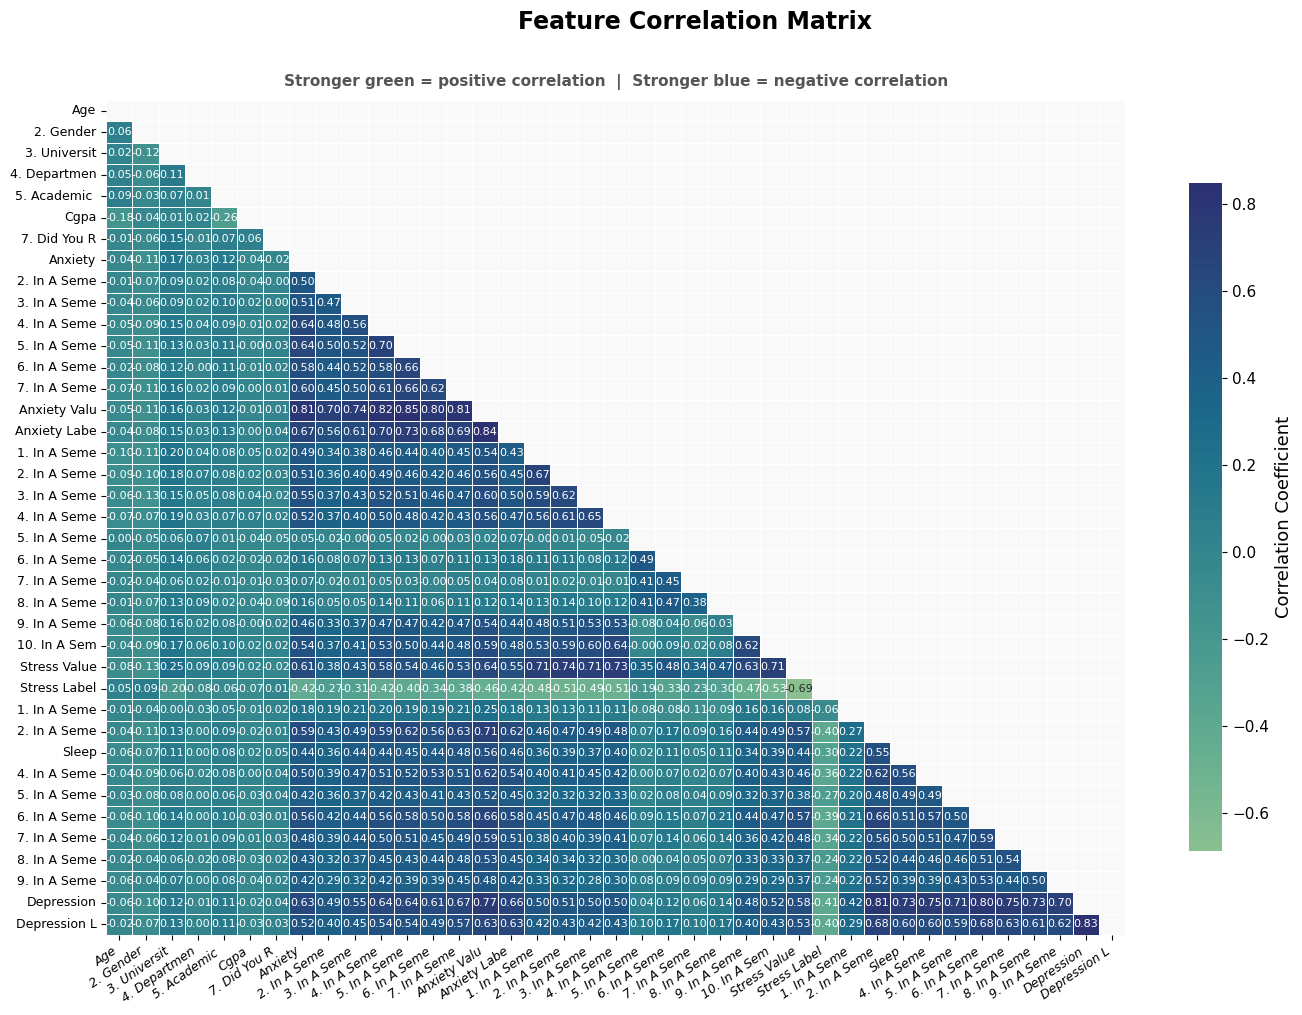

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Create a temporary copy of df to perform encoding for correlation calculation
# This ensures the original df state is preserved until the dedicated encoding cell (I2ejdXVPnc8g) is run.
temp_df = df.copy()

# Identify categorical columns for encoding
cat_cols_for_corr = temp_df.select_dtypes(include='object').columns.tolist()

# Apply LabelEncoder to convert categorical columns to numeric
le = LabelEncoder()
for col in cat_cols_for_corr:
    temp_df[col] = le.fit_transform(temp_df[col].astype(str))

# Now calculate correlation on the numerically encoded temporary DataFrame
corr = temp_df.corr()

short_names = {col: col.replace('_', ' ').title()[:12] for col in corr.columns}
corr.rename(index=short_names, columns=short_names, inplace=True)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Feature Correlation Matrix', fontsize=17, fontweight='bold', y=1.01)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='crest', center=0,
            linewidths=0.6, linecolor='white',
            annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Stronger green = positive correlation  |  Stronger blue = negative correlation',
             fontsize=11, color='#555555', pad=10)

for label in ax.get_xticklabels():
    label.set_rotation(35)
    label.set_ha('right')
    label.set_fontstyle('italic')
    label.set_fontsize(9)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

##3. Feature Engineering

Dropping irrelevant columns that add noise without predictive value.

Encoding remaining categorical columns to numeric for model training.

In [10]:
df.drop(columns=['id', 'University', 'Department'], inplace=True, errors='ignore')
df.columns.tolist()

['Age',
 '2. Gender',
 '3. University',
 '4. Department',
 '5. Academic Year',
 'CGPA',
 '7. Did you receive a waiver or scholarship at your university?',
 'Anxiety',
 '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ',
 '3. In a semester, how often have you had trouble relaxing due to academic pressure? ',
 '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?',
 '5. In a semester, how often have you worried too much about academic affairs? ',
 '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?',
 '7. In a semester, how often have you felt afraid, as if something awful might happen?',
 'Anxiety Value',
 'Anxiety Label',
 '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ',
 '2. In a semester, how often you felt as if you were unable to control important things in your academic af

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Age,2. Gender,3. University,4. Department,5. Academic Year,CGPA,7. Did you receive a waiver or scholarship at your university?,Anxiety,"2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?",Sleep,"4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression,Depression Label
0,0,0,8,2,1,0,0,1,1,1,...,2,1,1,2,1,1,1,1,11,2
1,0,1,8,2,0,3,0,2,2,1,...,1,1,1,1,1,1,1,1,9,0
2,0,1,8,2,0,1,0,2,1,1,...,0,2,3,2,2,2,2,1,16,3
3,0,1,8,2,0,2,0,2,1,1,...,1,1,1,1,1,1,1,1,9,0
4,0,1,8,2,0,2,0,1,1,1,...,1,1,1,1,1,1,1,1,9,0


## Feature Engineering Decisions

**Columns dropped:**
- `id` — row identifier only, carries zero predictive information
- `University` and `Department` — high cardinality categorical columns
  that add noise without meaningful signal toward depression prediction

**Columns kept and why:**
- `Sleep` (correlation: 0.73) — strongest predictor of depression
- `Anxiety` (correlation: 0.63) — second strongest predictor
- `Age`, `CGPA`, `Gender`, `Academic Year`, `Scholarship` — demographic
  context that may contribute mild predictive signal

**Columns excluded from X to prevent data leakage:**
- `Depression Label`, `Anxiety Label`, `Stress Label`,
  `Anxiety Value`, `Stress Value` — these are directly derived
  from the target variable and would cause artificially perfect accuracy

##4. Data Preprocessing

Splitting into train and test sets then standardizing features
so all variables contribute equally during model training.

In [12]:
feature_cols = [
    'Age',
    'CGPA',
    '2. Gender',
    '3. University',
    '4. Department',
    '5. Academic Year',
    '7. Did you receive a waiver or scholarship at your university?',
    'Anxiety',
    'Sleep',
]

X = df[feature_cols]
y = df['Depression']

f'Features: {X.shape} | Target: {y.shape}'

'Features: (1977, 9) | Target: (1977,)'

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
f'Train: {X_train.shape} | Test: {X_test.shape}'

'Train: (1581, 9) | Test: (396, 9)'

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
print(X.columns.tolist())
print(X.dtypes)
print(X.shape)

['Age', 'CGPA', '2. Gender', '3. University', '4. Department', '5. Academic Year', '7. Did you receive a waiver or scholarship at your university?', 'Anxiety', 'Sleep']
Age                                                               int64
CGPA                                                              int64
2. Gender                                                         int64
3. University                                                     int64
4. Department                                                     int64
5. Academic Year                                                  int64
7. Did you receive a waiver or scholarship at your university?    int64
Anxiety                                                           int64
Sleep                                                             int64
dtype: object
(1977, 9)


In [16]:
# Check correlation of every feature with Depression
corr = X.join(y).corr()['Depression'].sort_values(ascending=False)
print(corr)

Depression                                                        1.000000
Sleep                                                             0.729589
Anxiety                                                           0.627624
3. University                                                     0.121203
5. Academic Year                                                  0.111401
7. Did you receive a waiver or scholarship at your university?    0.036304
4. Department                                                    -0.005508
CGPA                                                             -0.021084
Age                                                              -0.056493
2. Gender                                                        -0.098510
Name: Depression, dtype: float64


##5. Model Training

Training three models and comparing performance using MSE and R².

The model with the lowest test loss will be saved as the best model.

In [17]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

f'Linear Regression — MSE: {lr_mse:.4f} | R2: {lr_r2:.4f}'

'Linear Regression — MSE: 16.6267 | R2: 0.6024'

## 6. Gradient Descent & Loss Curve

Optimizing using gradient descent and plotting train vs test loss
to confirm the model learns without overfitting.

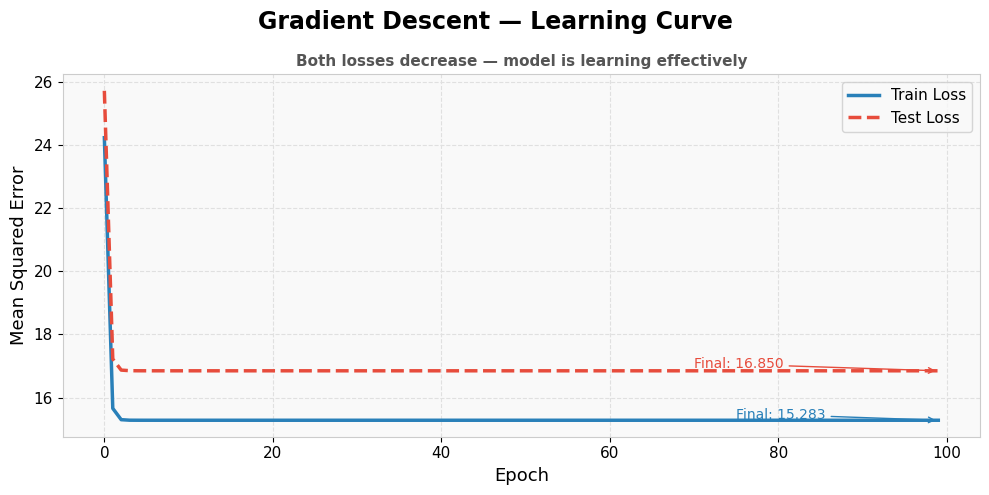

In [18]:
train_losses, test_losses = [], []

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   learning_rate='constant', eta0=0.001)

for _ in range(100):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gradient Descent — Learning Curve', fontsize=17, fontweight='bold')

ax.plot(train_losses, label='Train Loss', color='#2980b9', linewidth=2.5)
ax.plot(test_losses, label='Test Loss', color='#e74c3c', linewidth=2.5, linestyle='--')

ax.annotate(f'Final: {train_losses[-1]:.3f}',
            xy=(99, train_losses[-1]),
            xytext=(75, train_losses[-1] + 0.05),
            fontsize=10, color='#2980b9',
            arrowprops=dict(arrowstyle='->', color='#2980b9'))

ax.annotate(f'Final: {test_losses[-1]:.3f}',
            xy=(99, test_losses[-1]),
            xytext=(70, test_losses[-1] + 0.08),
            fontsize=10, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Both losses decrease — model is learning effectively',
             fontsize=11, color='#555555')
ax.legend()
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Decision Tree & Random Forest


In [19]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)

dt_preds = dt.predict(X_test_scaled)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

f'Decision Tree — MSE: {dt_mse:.4f} | R2: {dt_r2:.4f}'

'Decision Tree — MSE: 18.0927 | R2: 0.5673'

In [20]:
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

f'Random Forest — MSE: {rf_mse:.4f} | R2: {rf_r2:.4f}'

'Random Forest — MSE: 18.0056 | R2: 0.5694'

## 8. Model Comparison & Save Best Model
Comparing all three models. Saving the one with the lowest test MSE.

In [21]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Test MSE': [lr_mse, dt_mse, rf_mse],
    'Test R2':  [lr_r2,  dt_r2,  rf_r2]
})

best_idx = results['Test MSE'].idxmin()
best_name = results.loc[best_idx, 'Model']
model_map = {'Linear Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

joblib.dump(model_map[best_name], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

display(results.set_index('Model').style.highlight_min(subset=['Test MSE'], color='#d4edda'))

f'Best model saved: {best_name}'

,Test MSE,Test R2
Model,,
Linear Regression,16.626656,0.602403
Decision Tree,18.092697,0.567346
Random Forest,18.005599,0.569428


'Best model saved: Linear Regression'

## 9. Scatter Plot — Before & After Regression Line
Visualizing the linear regression fit on the most correlated feature
to show how the model draws a line through the data.

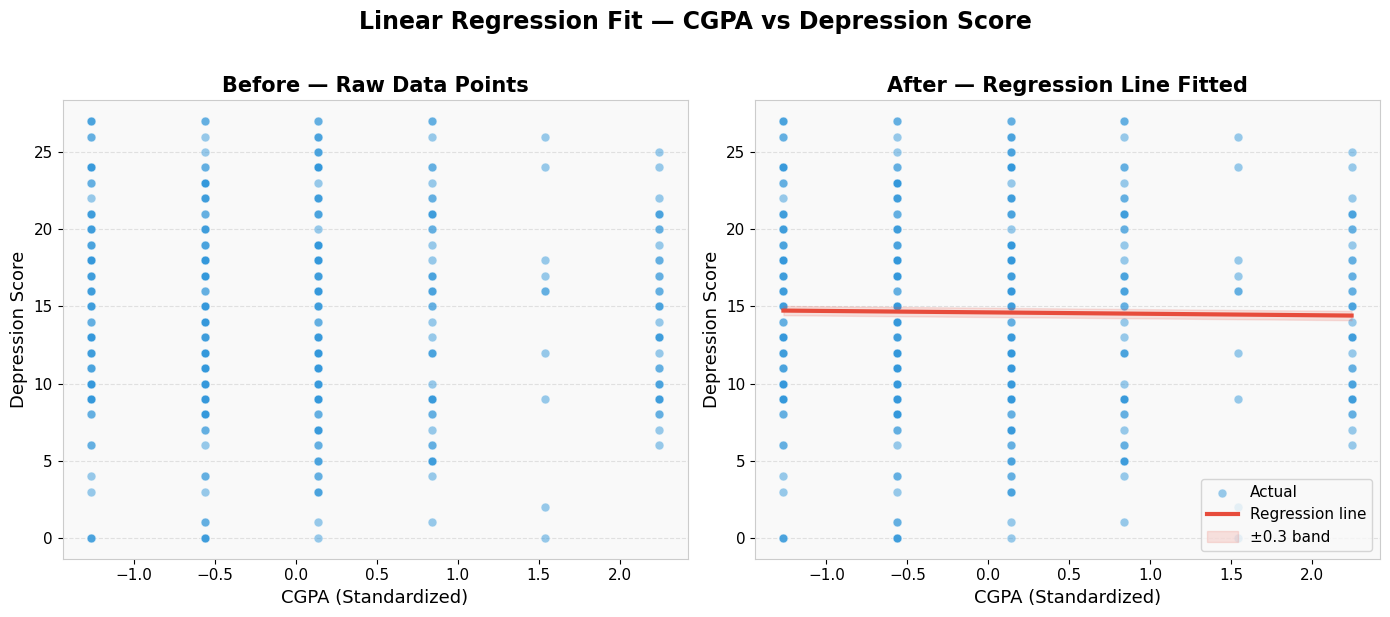

In [22]:
idx = list(X.columns).index('CGPA')
x_vals = X_test_scaled[:, idx]

lr1d = LinearRegression().fit(x_vals.reshape(-1, 1), y_test)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
y_line = lr1d.predict(x_line.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression Fit — CGPA vs Depression Score',
             fontsize=17, fontweight='bold', y=1.02)

axes[0].scatter(x_vals, y_test, alpha=0.5, color='#3498db',
                edgecolors='white', linewidth=0.5, s=40)
axes[0].set_title('Before — Raw Data Points')
axes[0].set_xlabel('CGPA (Standardized)')
axes[0].set_ylabel('Depression Score')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

axes[1].scatter(x_vals, y_test, alpha=0.5, color='#3498db',
                edgecolors='white', linewidth=0.5, s=40, label='Actual')
axes[1].plot(x_line, y_line, color='#e74c3c', linewidth=3, label='Regression line')
axes[1].fill_between(x_line, y_line - 0.3, y_line + 0.3,
                     alpha=0.15, color='#e74c3c', label='±0.3 band')
axes[1].set_title('After — Regression Line Fitted')
axes[1].set_xlabel('CGPA (Standardized)')
axes[1].set_ylabel('Depression Score')
axes[1].legend()
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 10. Single Student Prediction
Using the best saved model to predict depression risk for one student
from the test set.

In [23]:
model = joblib.load('best_model.pkl')
sc = joblib.load('scaler.pkl')

sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
pred = model.predict(sc.transform(sample))[0]

display(pd.DataFrame({
    'Metric': ['Actual Depression Score', 'Predicted Depression Score'],
    'Value':  [actual, round(pred, 2)]
}).set_index('Metric'))

,Value
Metric,
Actual Depression Score,18.0
Predicted Depression Score,19.6
